In [35]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from fontTools.misc.bezierTools import epsilon

from geodesics import *
import math
from pathlib import Path
np.random.seed(42)
random.seed(42)

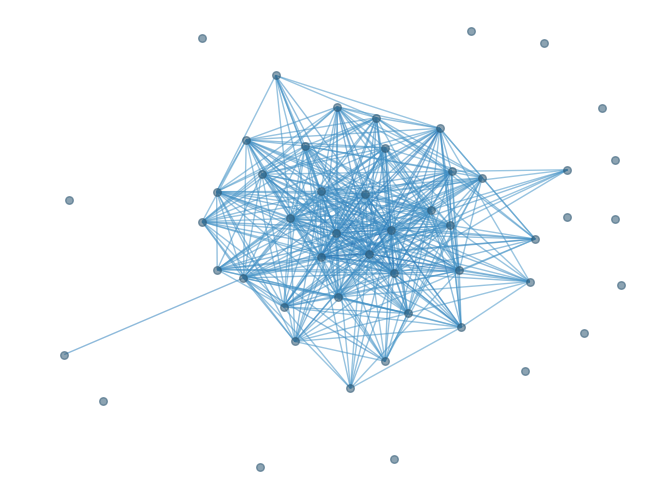

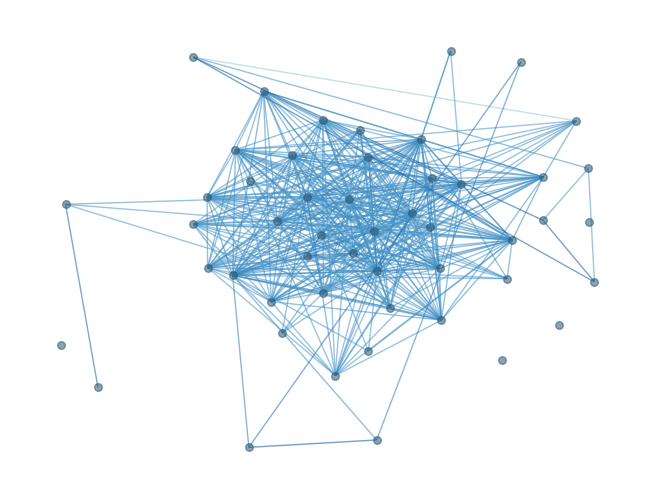

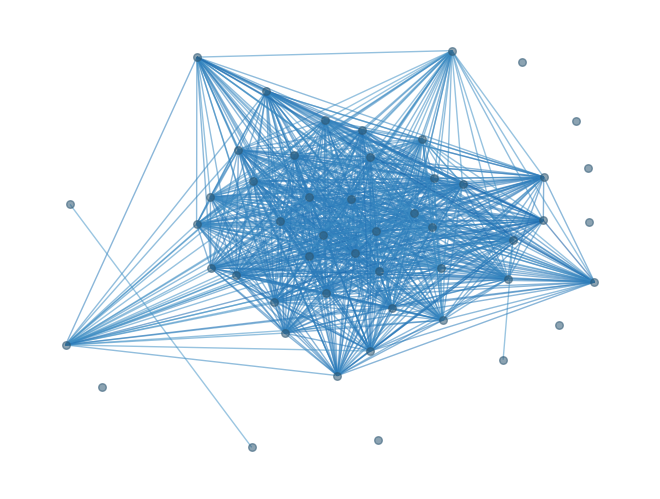

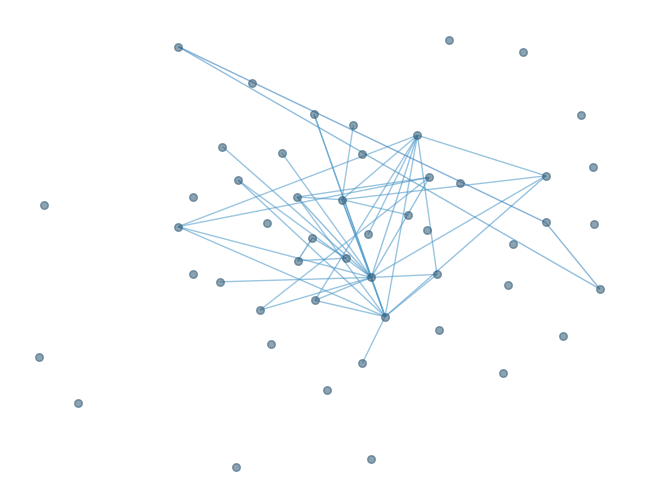

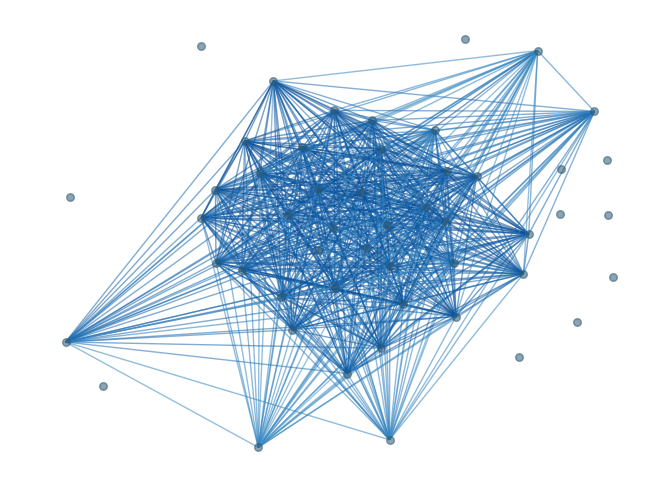

In [36]:
data_subdir = "slice_correlations/S02"
threshold = 0.2

use_all_data = True
do_transform = True
n_top_entries = 50

current_dir = Path.cwd()
output_dir = current_dir / "Outputs" / data_subdir / f"threshold {threshold}"
output_dir.mkdir(parents=True, exist_ok=True)
graph_dir = output_dir/ "graphs"
graph_dir.mkdir(parents=True, exist_ok=True)
plot_dir = output_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

data_root_path = current_dir.parents[1] / "Data" / data_subdir
filenames = ["corr_E14_16.csv", "corr_E16_18.csv", "corr_L1.csv",  "corr_L2.csv",   "corr_L3.csv"]
data_path = [data_root_path / file for file in filenames]
correlation_pd = [pd.read_csv(corr_file) for corr_file in data_path]
for correlation in correlation_pd:
    correlation.fillna(0, inplace=True)

datas =  [dataframe.iloc[:,1:].values for dataframe in correlation_pd]

indices_temp  = np.zeros(n_top_entries*5,dtype=int)
for i,data in enumerate(datas):
    if not use_all_data:
        np.fill_diagonal(data, 0)
        indices_temp[i*n_top_entries:(i+1)*n_top_entries] = np.argpartition(np.abs(np.max(np.abs(data),axis=1)),-n_top_entries)[-n_top_entries:]
    else:
        np.fill_diagonal(data, 0.5)


if not use_all_data:
    indices = np.unique(indices_temp)
    for i,data in enumerate(datas):
        datas[i] = data[indices][:, indices]

if do_transform:
    for i,data in enumerate(datas):
        datas[i] = 1/2*data+1/2
        np.fill_diagonal(datas[i], 0.5)



# threshold based on absolute value of untransformed data (per sandhu) to build topology.
# weights come for the transformed data I guess

graphs = [nx.from_numpy_array(np.where(abs(data*2-1) > threshold,data,0)) for data in datas]

cmap = plt.cm.Blues
pos = nx.spring_layout(graphs[0],scale=1)

connected_vertices = nx.connected_components(graphs[0])
S = [graphs[0].subgraph(c) for c in connected_vertices]
for subgraph in S:
    if subgraph.order() > 1:
        pos_S = nx.kamada_kawai_layout(subgraph,scale=1)
        pos.update(pos_S)

for i,graph in enumerate(graphs):
    fig = plt.figure()
    edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
    nx.draw(graph, pos, edge_color=weights, width=1, edge_cmap=cmap,edge_vmin = 0,edge_vmax=1,node_size=30,alpha=0.55,node_color="#2e5873"),
    #plt.title(f"Number of Edges: {len(edges)}")
    fig.savefig(graph_dir / f"graph_{i}.pdf",transparent=True)

In [37]:
tvalues = np.linspace(0, 1, num=11)

#geodesics for all pairs
geodesic_pairs = []
for graph1, graph2 in zip(graphs, graphs[1:]):
    geodesic_pairs.append(compute_GW_Geodesics_weighted(graph1,graph2, tvalues,weight_inf_treshold=0, inf_treshold=1e4,threshold_down=0.75, threshold_up=1.25, delete_high_weights=False,
    )[0])

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.987132e+07|0.000000e+00|0.000000e+00
    1|6.013646e+05|8.193025e+01|4.926996e+07
    2|6.023947e+03|9.882901e+01|5.953407e+05
    3|6.024075e+01|9.899787e+01|5.963706e+03
    4|6.024077e-01|9.899997e+01|5.963834e+01
    5|6.023999e-03|9.900129e+01|5.963837e-01
    6|6.021119e-05|9.904784e+01|5.963788e-03
    7|6.613649e-07|9.004080e+01|5.954983e-05
    8|2.223454e-08|2.874494e+01|6.391303e-07
    9|7.629713e-09|1.914204e+00|1.460482e-08
   10|7.599893e-09|3.923631e-03|2.981918e-11
   11|7.599595e-09|3.923785e-05|2.981918e-13
   12|7.599592e-09|3.923787e-07|2.981918e-15
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.831192e+07|0.000000e+00|0.000000e+00
    1|3.255497e+07|4.840108e-01|1.575696e+07
    2|3.238339e+07|5.298407e-03|1.715804e+05
    3|3.238167e+07|5.303015e-05|1.717205e+03
    4|3.238165e+07|5.303061e-07|1.717219e+0

In [38]:
#generate plots of geodesic graphs

# for pair in [0,1,2,3]:
#     for i,graph in enumerate(geodesic_pairs[pair]):
#         fig = plt.figure()
#         edges,weights = zip(*nx.get_edge_attributes(graph,'weight').items())
#         nx.draw(graph, pos, edge_color=weights, width=1, edge_cmap=cmap,edge_vmin = 0,edge_vmax=1,node_size=30,alpha=0.55,node_color="#2e5873"),
#         fig.savefig(graph_dir / f"graph_{pair}_{i}.pdf",transparent=True)


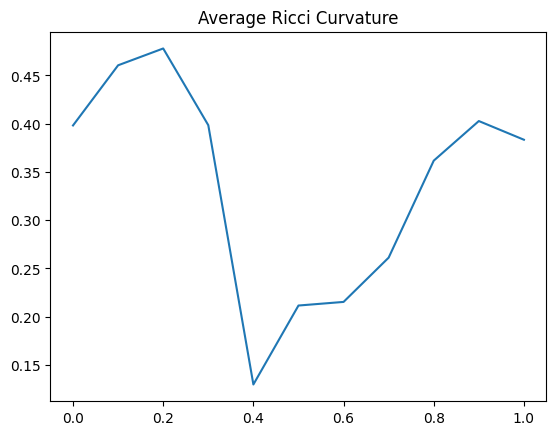

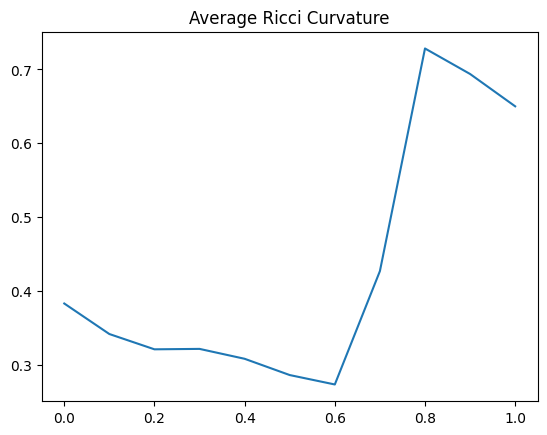

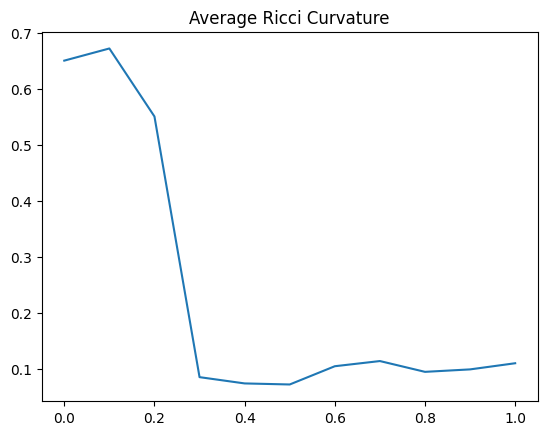

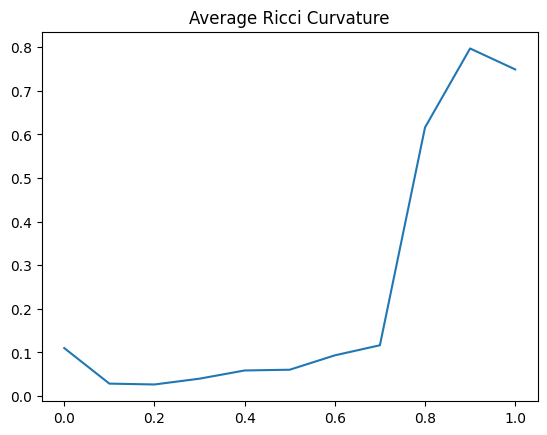

In [39]:
OR_curvatures = []
for i,geodesic_pair in enumerate(geodesic_pairs):
    OR_curvatures.append(compute_curvature_OR(geodesic_pair))
    plot_avg_curvature(tvalues,OR_curvatures[-1])
    plt.savefig(plot_dir / f"g{i}_{i+1}.pdf",transparent=True)


In [40]:
#geodesic for first to final
t_values_final = np.linspace(0,1,num=40)
geodesic_final,_ =compute_GW_Geodesics_weighted(graphs[0],graphs[-1], t_values_final,weight_inf_treshold=0.0, inf_treshold=1e4,threshold_down=0.75, threshold_up=1.25, delete_high_weights=False,
    )

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.987132e+07|0.000000e+00|0.000000e+00
    1|6.013646e+05|8.193025e+01|4.926996e+07
    2|6.023947e+03|9.882901e+01|5.953407e+05
    3|6.024075e+01|9.899787e+01|5.963706e+03
    4|6.024077e-01|9.899997e+01|5.963834e+01
    5|6.023999e-03|9.900129e+01|5.963837e-01
    6|6.021119e-05|9.904784e+01|5.963788e-03
    7|6.613649e-07|9.004080e+01|5.954983e-05
    8|2.223454e-08|2.874494e+01|6.391303e-07
    9|7.629713e-09|1.914204e+00|1.460482e-08
   10|7.599893e-09|3.923631e-03|2.981918e-11
   11|7.599595e-09|3.923785e-05|2.981918e-13
   12|7.599592e-09|3.923787e-07|2.981918e-15
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.944660e+07|0.000000e+00|0.000000e+00
    1|9.350323e+06|4.288224e+00|4.009627e+07
    2|8.881352e+06|5.280392e-02|4.689703e+05
    3|8.876656e+06|5.290847e-04|4.696503e+03
    4|8.876609e+06|5.291305e-06|4.696885e+0

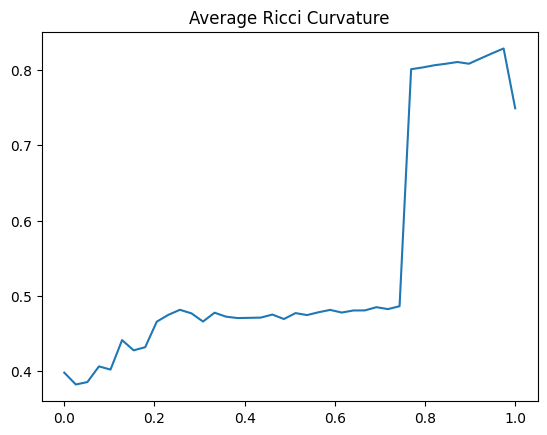

In [41]:
final_curvatures = compute_curvature_OR(geodesic_final)
plot_avg_curvature(t_values_final,final_curvatures)
plt.savefig(plot_dir / f"g0_4.pdf",transparent=True)

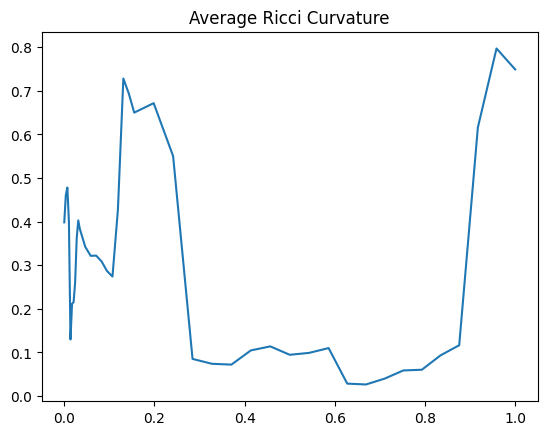

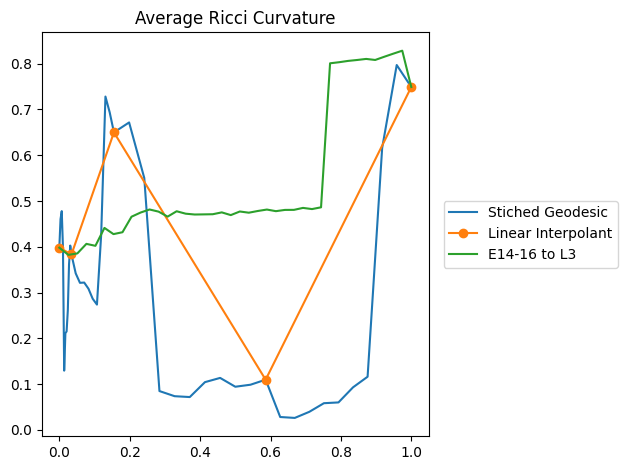

In [42]:
times = [15,17,24,49,49+24]
total= times[-1] - times[0]
new_t_values = []

connected_curvature = []
for i,curvatures in enumerate(OR_curvatures):
    if i >= 1:
        new_t_values= np.append(new_t_values,new_t_values[-1]+tvalues/total*(times[i+1]-times[i]))
    else:
        new_t_values= np.append(new_t_values,tvalues/total*(times[i+1]-times[i]))
    connected_curvature += curvatures

plot_avg_curvature(new_t_values,connected_curvature)
plt.savefig(plot_dir / f"gstiched.pdf",transparent=True)

realavgs = []
for kappas in OR_curvatures:
    realavgs.append(np.average(kappas[0]))
realavgs.append(np.average(OR_curvatures[-1][-1]))
plot_avg_curvature(new_t_values,connected_curvature)
times_normalized =  [(t - times[0]) / total for t in times]
plt.plot(times_normalized,realavgs,marker="o")

avg = np.zeros(len(final_curvatures))
for i, kappa in enumerate(final_curvatures):
    avg[i] = np.average(kappa)

plt.plot(t_values_final,avg)
plt.legend(["Stiched Geodesic","Linear Interpolant","E14-16 to L3"],loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.savefig(plot_dir / f"gstiched_overlayed.pdf",transparent=True)


In [43]:
def relaxed_sign(x,epsilon):
    if abs(x) < epsilon:
        return 0
    else:
        return np.sign(x)

times = [15, 17, 24, 49, 49 + 24]
total = times[-1] - times[0]
epsilon = 0.1

avg = np.zeros(len(t_values_final))
sgn_assignment = np.zeros(len(t_values_final)-1)
sgn_assignment_relaxed = np.zeros(len(t_values_final)-1)
delta_real_relaxed = np.zeros(len(t_values_final)-1)

for i, kappa in enumerate(final_curvatures):
    avg[i] = np.average(kappa)

realavgs = []
for kappas in OR_curvatures:
    realavgs.append(np.average(kappas[0]))
realavgs.append(np.average(OR_curvatures[-1][-1]))

j = 0
for i,t_initial in enumerate(times[:-1]):
    leftside = (t_initial - times[0]) / total
    rightside = (times[i+1] - times[0]) /total
    delta_real_sgn = np.sign(realavgs[i+1] - realavgs[i])

    interpolant = lambda t: (t- leftside)/(rightside-leftside)*realavgs[i+1] + (t- rightside)/(leftside-rightside)*realavgs[i]
    while t_values_final[j] < rightside:
        #interpolant =
        sgn_assignment[j]  = np.sign(avg[j+1] -avg[j]) == delta_real_sgn
        delta_real_relaxed[j] = interpolant(t_values_final[j+1])- interpolant(t_values_final[j])

        delta_real_relaxed_sgn = relaxed_sign(interpolant(t_values_final[j+1])- interpolant(t_values_final[j]), epsilon)

        sgn_assignment_relaxed[j] = relaxed_sign(avg[j+1] - avg[j],epsilon) == delta_real_relaxed_sgn
        j+=1

sgn_value = np.average(sgn_assignment)
sgn_value_relaxed = np.average(sgn_assignment_relaxed)
print(sgn_value,sgn_value_relaxed)

0.5641025641025641 0.9743589743589743


In [44]:
ricci_times = np.logspace(-2.0, 1, 7)
dynamic_curvatures = []
for i, geodesic_pair in enumerate(geodesic_pairs):
    dynamic_curvatures.append(compute_curvature_dynamic(geodesic_pair,ricci_times))
    figs = plot_dynamic_curvature(tvalues, ricci_times,dynamic_curvatures[-1])
    for j,fig in enumerate(figs):
        fig.savefig(plot_dir / f"dynamic curvatures g{i}_{i + 1} geotime {tvalues[j]}.pdf", transparent=True)
        plt.close(fig)

100%|██████████| 7/7 [00:02<00:00,  2.84it/s]


In [45]:
dynamic_final_curvatures = compute_curvature_dynamic(geodesic_final,ricci_times)
# figs = plot_dynamic_curvature(t_values_final, ricci_times,dynamic_final_curvatures)
# for geotime,fig in zip(t_values_final,figs):
#         fig.savefig(main_dir / f"dynamic curvatures g0_4 geotime {geotime}.pdf", transparent=True)
#         plt.close(fig)

IndentationError: unexpected indent (1171185852.py, line 1)

In [119]:
def plot_dynamic_averages(geodesic_time, dynamic_ricii_times, kappa_values):
    avg = np.zeros((len(dynamic_ricii_times),len(geodesic_time)))
    for i, kappa in enumerate(kappa_values):
        avg[:,i] = np.average(kappa,axis=1)

    fig = plt.figure()
    plt.title("Average Dynamic Ricci Curvatures")
    plt.plot(geodesic_time, np.transpose(avg))
    plt.legend([f"$\\tau=\\log_{{10}}({time})$" for time in dynamic_ricii_times], title="Diffusion Parameter",loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()


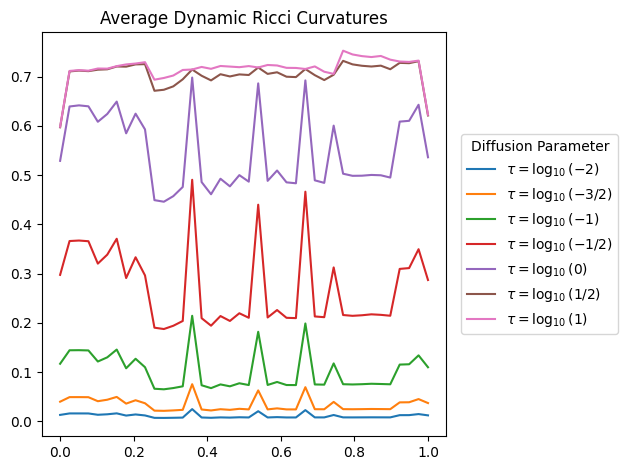

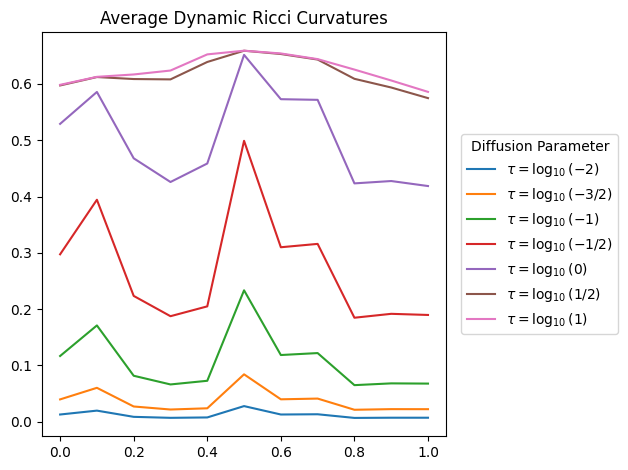

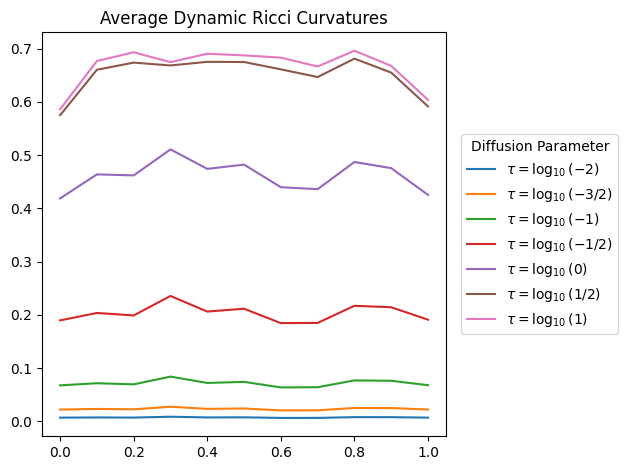

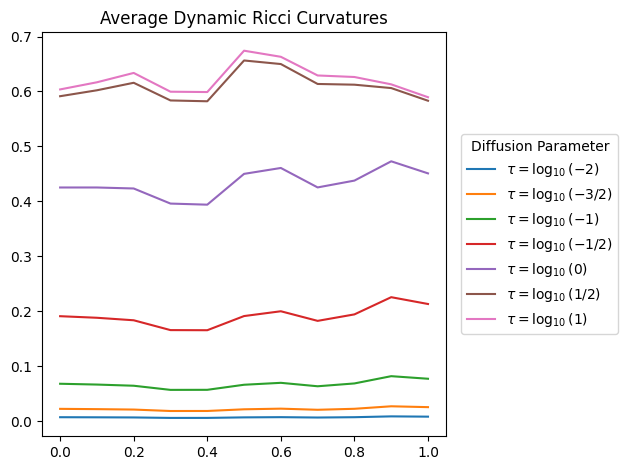

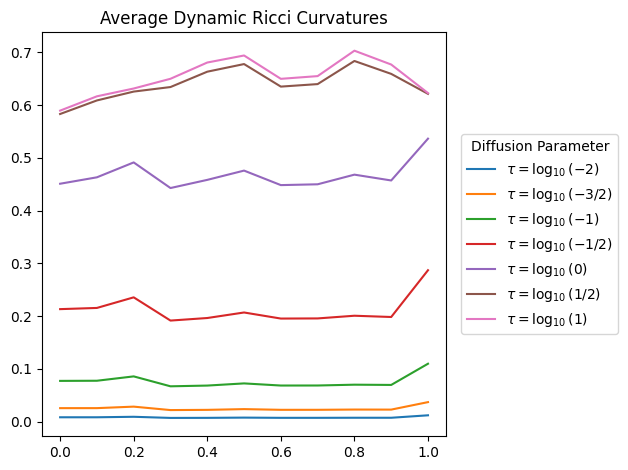

In [120]:
#ricci_times_nice = ["-2","-5/3","-4/3","-1","-2/3","-1/3","0","1/3","2/3","1"]
ricci_times_nice = ["-2","-3/2","-1","-1/2","0","1/2","1"]

plot_dynamic_averages(t_values_final,ricci_times_nice,dynamic_final_curvatures)
plt.savefig(plot_dir / f"dynamic g0_4.pdf",transparent=True)

for i,curvature in enumerate(dynamic_curvatures):
    plot_dynamic_averages(tvalues,ricci_times_nice,curvature)
    plt.savefig(plot_dir / f"dynamic g{i}_{i + 1}.pdf", transparent=True)
